In [1]:
import GEOparse

gse_tumor = GEOparse.get_GEO("GSE4271", destdir="../data/raw/geo",silent=True)
gse_normal = GEOparse.get_GEO("GSE11882", destdir="../data/raw/geo",silent=False)

c:\Users\haina\AppData\Local\Programs\Python\Python311\Lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (0: SPOT_ID) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


In [18]:
import pandas as pd
import numpy as np



tumor_expr = gse_tumor.pivot_samples('VALUE')
normal_expr = gse_normal.pivot_samples('VALUE')

        exprs.append(expr)

    merged = exprs[0]

    for e in exprs[1:]:
        merged = merged.merge(e, on="probe")

    return merged.set_index("probe")

tumor_expr = build_expr_matrix(gse_tumor)
normal_expr = build_expr_matrix(gse_normal)

mmc2_df = pd.read_csv("../data/interim/mmc2_metadata.csv")
mmc2_df = mmc2_df.set_index("id")

In [19]:
tumor_expr = np.log2(tumor_expr + 1)
normal_expr = np.log2(normal_expr + 1)

if isinstance(normal_expr, pd.DataFrame):
    normal_expr["row_mean"] = normal_expr.mean(axis=1)
    normal_expr = normal_expr["row_mean"]

def choose_higher_ab(expression_df, metadata_df):
    selected = {}

    for patient_id, row in metadata_df[["A", "B"]].iterrows():
        sample_a = row["A"]
        sample_b = row["B"]

        if pd.isna(sample_a) and pd.isna(sample_b):
            continue

        if pd.notna(sample_a) and pd.notna(sample_b):
            if sample_a not in expression_df.columns or sample_b not in expression_df.columns:
                continue

            expr_a = expression_df[sample_a]
            expr_b = expression_df[sample_b]
            selected[patient_id] = pd.concat([expr_a, expr_b], axis=1).max(axis=1, skipna=True)
        elif pd.notna(sample_a) and sample_a in expression_df.columns:
            selected[patient_id] = expression_df[sample_a]
        elif pd.notna(sample_b) and sample_b in expression_df.columns:
            selected[patient_id] = expression_df[sample_b]

    return pd.DataFrame(selected)


chosen_expr = choose_higher_ab(tumor_expr, mmc2_df)

print("chosen_expr shape:", chosen_expr.shape)
print("chosen_expr nonzero count:", (chosen_expr != 0).sum().sum())
print("chosen_expr min/max:", chosen_expr.min().min(), chosen_expr.max().max())

chosen_expr.to_csv("../data/interim/tumor_expr_by_patient.csv")

gene_expr shape: (21290, 100)
gene_expr nonzero count: 2129000
gene_expr min/max: 0.13750352374993502 17.49827892021279


In [21]:
gpl1 = gse_tumor.gpls["GPL96"]
gpl2 = gse_tumor.gpls["GPL97"]

gene_id1 = gpl1.table[["ID", "Gene Symbol"]]
gene_id2 = gpl2.table[["ID", "Gene Symbol"]]

gene_id = pd.concat([gene_id1, gene_id2], axis=0)
gene_id = gene_id.rename(columns={"ID": "ID_REF"}).set_index("ID_REF")
gene_id = gene_id.copy()
gene_id["Gene Symbol"] = gene_id["Gene Symbol"].str.strip()
gene_id = gene_id[
    (gene_id["Gene Symbol"].notna()) &
    (gene_id["Gene Symbol"] != "") &
    (gene_id["Gene Symbol"] != "---")
]

gene_expr = chosen_expr.merge(
    gene_id,
    left_index=True,
    right_index=True,
    how="inner"
)

gene_expr = gene_expr.set_index("Gene Symbol")

def expand_multigene_probes(df):
    df = df.copy()
    df = df.reset_index().rename(columns={"index": "Gene Symbol"})
    df["Gene Symbol"] = df["Gene Symbol"].str.split(" /// ")
    df = df.explode("Gene Symbol")
    df["Gene Symbol"] = df["Gene Symbol"].str.strip()
    df = df[df["Gene Symbol"] != ""]
    df = df.set_index("Gene Symbol")
    return df


gene_expr = expand_multigene_probes(gene_expr)
gene_expr = gene_expr.groupby(level=0).max()

print("gene_expr shape:", gene_expr.shape)
print("gene_expr nonzero count:", (gene_expr != 0).sum().sum())
print("gene_expr min/max:", gene_expr.min().min(), gene_expr.max().max())

gene_expr.to_csv("../data/interim/tumor_expr_by_gene.csv")

gene_expr shape: (130, 100)
gene_expr nonzero count: 13000
gene_expr min/max: 8.11790278909403 17.232191365398826


In [22]:
gene_expr

,3744,3745,3746,3747,3748,3749,3751,3752,3753,3754,...,4785,4787,4788,4790,4791,4793,5063,5070,9907,9938
Gene Symbol,,,,,,,,,,,,,,,,,,,,,
ABCF1,11.704206,11.538528,12.417642,12.079818,12.577523,11.772232,11.969854,12.041625,12.326064,12.265175,...,12.445687,11.444653,11.832020,11.712656,12.435722,11.643180,11.494006,11.085273,11.409762,11.620266
ACTB,16.167165,16.221732,16.290595,15.400599,15.989847,15.335212,15.484046,15.833251,15.855504,15.846193,...,15.732080,15.575985,15.370320,15.581992,15.654921,15.131447,15.149783,15.154379,15.445112,15.447868
ANAPC5,11.907867,12.584869,11.777050,11.876786,12.171802,12.065685,12.350083,12.099512,12.377671,11.953251,...,11.902601,12.025347,12.497228,12.410239,12.589955,11.812578,11.928740,12.023269,11.709256,11.614296
ARF1,13.695718,13.819710,13.976788,13.493268,14.299101,13.268440,14.084102,14.013890,13.890464,13.890701,...,13.631268,13.864351,13.268513,12.710419,13.693138,13.409855,13.105990,13.666268,13.707823,13.500929
ARF3,12.781319,12.213712,12.770106,13.048095,12.773345,13.060189,13.207853,13.290004,12.916122,12.951157,...,12.770746,13.092229,12.833819,12.535713,12.179132,12.832297,13.279567,12.756556,13.588281,13.726740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TMED2,13.092988,13.999216,13.036483,12.791631,13.526291,11.931107,12.714052,13.296615,13.577712,13.314838,...,12.966253,13.143064,12.895253,12.322238,13.017713,12.797682,12.929055,13.041163,12.334553,13.348853
USP22,12.442347,11.834155,12.334162,12.592901,12.788555,12.604901,12.940185,12.593111,12.737902,12.558540,...,12.449742,12.629015,12.531820,12.389820,12.881573,12.248194,12.865675,12.574097,12.265117,12.011716
YY1,11.918453,12.251187,11.759306,10.909293,12.052568,11.248224,11.746430,11.965676,12.121372,12.090245,...,12.209453,11.987619,12.372130,11.883445,12.029908,12.292005,11.845725,11.559903,11.271930,11.922993


In [ ]:
gene_expr

,3744,3745,3746,3747,3748,3749,3751,3752,3753,3754,...,4785,4787,4788,4790,4791,4793,5063,5070,9907,9938
Gene Symbol,,,,,,,,,,,,,,,,,,,,,
A1BG,9.707359,6.850499,8.732337,7.840463,8.840148,8.047124,8.794091,9.785452,9.558229,7.666757,...,9.038645,8.588340,7.822730,8.095397,8.662134,8.188836,8.162391,8.763876,7.343408,8.489045
A1BG-AS1,5.189825,4.554589,5.689299,5.652486,5.121015,5.738768,7.098032,8.044940,5.395748,5.040016,...,5.339850,5.161888,7.229780,5.228819,6.475733,5.897240,5.569856,5.517276,5.683696,5.368070
A1CF,7.642413,8.219169,8.295539,7.832890,7.986980,8.663202,7.683696,8.247928,7.802193,8.609179,...,8.544964,8.293702,7.888743,8.506605,8.381543,8.401306,9.141085,9.040564,8.671364,7.464342
A2M,12.205457,12.075980,12.233290,11.356012,13.271740,11.945334,11.686588,12.746472,12.450928,11.852803,...,12.506630,13.342880,11.864186,12.662090,11.315093,12.521797,12.074275,11.900527,12.240195,11.907416
A2MP1,9.449355,9.441077,9.215533,8.561097,8.935165,8.418274,6.797013,6.529821,7.621319,8.282162,...,8.598425,8.725196,8.829088,8.446256,8.288635,8.606590,8.314697,8.731319,9.151270,8.599913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hADV36S1,6.329124,5.112700,5.708739,6.033423,5.539159,3.498251,2.847997,5.885086,6.575917,7.880196,...,5.970394,4.632268,5.409391,3.217231,4.925999,5.719731,6.050937,5.456149,4.542258,5.880196
hsa-let-7a-3,7.556123,9.664269,8.641329,9.828613,8.735725,10.277171,8.666757,8.087463,7.834155,9.133142,...,8.102238,7.833523,9.494656,9.276822,8.891480,8.678072,5.961160,8.096452,8.611763,5.478972
hsa-let-7b,7.556123,9.664269,8.641329,9.828613,8.735725,10.277171,8.666757,8.087463,7.834155,9.133142,...,8.102238,7.833523,9.494656,9.276822,8.891480,8.678072,5.961160,8.096452,8.611763,5.478972


In [7]:
normal_expr = np.log2(normal_expr + 1)
normal_expr

name,GSM300166,GSM300167,GSM300168,GSM300169,GSM300170,GSM300171,GSM300172,GSM300173,GSM300174,GSM300175,...,GSM300331,GSM300332,GSM300333,GSM300335,GSM300338,GSM300339,GSM300340,GSM300341,GSM318840,GSM350078
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,0.916871,1.284229,1.383830,1.462031,1.496069,1.286687,1.371638,0.608535,0.845245,0.674539,...,1.008148,1.221902,1.459881,0.931036,0.848156,1.269840,1.092919,0.826264,1.065058,0.941141
1053_at,0.736787,0.915217,1.515550,1.026210,1.275837,1.313266,1.128486,0.908140,0.939389,1.013053,...,1.026711,0.911766,0.697642,1.045972,0.962298,0.915136,1.139658,1.000685,0.673456,0.801981
117_at,0.895022,1.044065,2.034707,1.697620,2.599390,3.887605,1.683152,0.867496,1.406343,0.785050,...,0.888167,1.197246,1.370850,0.874500,0.951557,1.302750,0.749911,1.016756,1.183530,0.815750
121_at,0.981962,1.036148,0.987164,1.136347,1.028236,0.833055,1.008566,1.105353,0.970915,0.932736,...,0.839384,1.034514,1.103467,0.903996,0.955502,0.969513,0.814975,1.134621,0.863081,0.815824
1255_g_at,0.576527,0.620610,2.063380,1.330151,1.671656,2.183215,1.683977,1.276465,2.587704,1.220464,...,0.609376,0.954587,2.380419,0.618509,1.250401,1.309399,0.690947,0.636578,0.550338,0.597557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AFFX-r2-Ec-bioC-5_at,0.970879,1.277609,0.780983,0.843685,0.838215,0.764001,0.743744,1.135516,1.108888,0.922178,...,0.978041,1.173110,1.164360,0.846561,0.994529,0.927337,0.923721,0.933210,1.296399,1.122735
AFFX-r2-Ec-bioD-3_at,1.139302,1.039145,1.053223,1.143091,1.132500,1.003450,1.137378,1.085985,1.101130,0.921767,...,0.974255,1.198996,1.088941,0.859364,1.072377,0.996874,0.958114,0.778643,1.073728,1.051003
AFFX-r2-Ec-bioD-5_at,1.112010,1.052013,1.049711,1.161700,1.128206,0.965324,1.147481,1.091480,1.082877,0.914830,...,0.926793,1.244222,1.065544,0.853411,1.021182,0.955294,0.922264,0.810508,1.150814,1.071244


In [8]:
# Clean and expand the normal probe-to-gene mapping
import pandas as pd

gene_id_normal = gse_normal.gpls["GPL570"].table[["ID", "Gene Symbol"]].copy()
gene_id_normal = gene_id_normal.rename(columns={"ID": "probe", "Gene Symbol": "gene_symbol"})
gene_id_normal = gene_id_normal[gene_id_normal["gene_symbol"].notna()]
gene_id_normal["gene_symbol"] = gene_id_normal["gene_symbol"].astype(str).str.strip().str.upper()
gene_id_normal = gene_id_normal[
    (gene_id_normal["gene_symbol"] != "")
    & (gene_id_normal["gene_symbol"] != "---")
    & (gene_id_normal["gene_symbol"].str.lower() != "nan")
]

def expand_multigene_probes(df):
    df = df.copy()
    df["gene_symbol"] = df["gene_symbol"].str.split(" /// ")
    df = df.explode("gene_symbol")
    df["gene_symbol"] = df["gene_symbol"].astype(str).str.strip().str.upper()
    df = df[df["gene_symbol"] != ""]
    return df.drop_duplicates().reset_index(drop=True)

probe_gene_df = expand_multigene_probes(gene_id_normal)
probe_gene_df

,probe,gene_symbol
0,1007_s_at,DDR1
1,1007_s_at,MIR4640
2,1053_at,RFC2
3,117_at,HSPA6
4,121_at,PAX8
...,...,...
50081,AFFX-HUMGAPDH/M33197_M_at,GAPDH
50082,AFFX-HUMISGF3A/M97935_3_at,STAT1
50083,AFFX-HUMISGF3A/M97935_5_at,STAT1
50084,AFFX-HUMISGF3A/M97935_MA_at,STAT1


In [9]:
# Expand-collapse the normal expression matrix by gene_symbol using normal_expr
import pandas as pd

normal_expr_df = normal_expr.copy()
if isinstance(normal_expr_df, pd.Series):
    normal_expr_df = normal_expr_df.to_frame(name="expression")

normal_expr_df.index.name = "probe"
normal_expr_df = normal_expr_df.reset_index()

if "probe" not in normal_expr_df.columns:
    normal_expr_df = normal_expr_df.rename(columns={normal_expr_df.columns[0]: "probe"})

normal_expr_by_gene = normal_expr_df.merge(
    probe_gene_df,
    on="probe",
    how="inner",
)

normal_expr_by_gene["gene_symbol"] = normal_expr_by_gene["gene_symbol"].astype(str).str.strip().str.upper()
normal_expr_by_gene = normal_expr_by_gene[normal_expr_by_gene["gene_symbol"] != ""]
normal_expr_by_gene = normal_expr_by_gene.set_index("gene_symbol")
normal_expr_by_gene = normal_expr_by_gene.drop(columns=["probe"], errors="ignore")
normal_expr_by_gene = normal_expr_by_gene.groupby(level=0).max()

print("normal_expr_by_gene shape:", normal_expr_by_gene.shape)
normal_expr_by_gene

normal_expr_by_gene shape: (24440, 173)


,GSM300166,GSM300167,GSM300168,GSM300169,GSM300170,GSM300171,GSM300172,GSM300173,GSM300174,GSM300175,...,GSM300331,GSM300332,GSM300333,GSM300335,GSM300338,GSM300339,GSM300340,GSM300341,GSM318840,GSM350078
gene_symbol,,,,,,,,,,,,,,,,,,,,,
A1BG,0.552666,0.594953,2.721970,2.419026,2.648238,2.769953,2.643360,0.612496,0.656632,0.597287,...,0.691014,0.585967,0.578886,0.645697,0.599067,0.598168,0.646147,0.615205,0.569548,0.670287
A1BG-AS1,0.889048,0.992251,1.145300,1.217288,1.104076,1.261322,1.261751,0.921443,0.891401,0.967666,...,1.276722,1.182978,1.199801,0.961459,1.004182,0.858650,0.743194,1.213322,0.953802,1.198017
A1CF,1.110384,0.993501,0.611625,0.581875,0.596026,0.504079,0.633594,0.942367,0.939863,0.922505,...,0.981304,0.977788,0.891161,0.974061,1.013167,0.974659,0.910476,1.013210,0.940974,0.964507
A2M,1.051818,0.851449,1.060468,1.590518,1.362097,1.396323,1.528924,0.886881,0.942483,0.982849,...,0.907233,1.227500,1.178834,0.826559,1.023689,1.114958,0.900057,0.930420,1.687596,0.845146
A2M-AS1,0.872077,1.185441,0.650835,1.181969,0.687648,0.456469,0.870001,0.754037,0.875876,0.874796,...,1.063304,1.220818,0.990514,1.089608,0.807330,0.950046,1.065395,0.966726,1.392995,1.691965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11A,0.667949,0.648017,0.329516,0.308207,0.323157,0.322428,0.347704,0.651363,0.663946,0.599968,...,0.626997,0.629620,0.622924,0.624925,0.662906,0.660732,0.549124,0.650926,0.608455,0.637724
ZYG11B,0.916000,0.935131,1.174000,0.944943,1.107079,0.890381,1.099375,1.239986,1.103532,1.250172,...,1.096333,0.769415,0.951403,1.095989,1.264604,1.062342,0.933352,1.003701,0.790865,1.332976
ZYX,1.257777,0.909861,1.337326,1.047217,1.322958,1.624076,1.276805,1.002837,0.613576,1.515804,...,1.374951,0.823774,0.781652,1.132762,0.832765,0.709045,1.524705,1.355589,1.124239,1.123515


In [10]:

# Check gene-symbol overlap between normal_expr_by_gene and gene_expr
normal_genes = set(normal_expr_by_gene.index.astype(str).str.upper())
tumor_genes = set(gene_expr.index.astype(str).str.upper())


shared_genes = gene_expr.index.intersection(normal_expr_by_gene.index)
tumor_expr = gene_expr.loc[shared_genes]
normal_expr = normal_expr_by_gene.loc[shared_genes]


combined = pd.concat(
    [tumor_expr, normal_expr],
    axis=1
)


normal_only_genes = normal_genes - tumor_genes
tumor_only_genes = tumor_genes - normal_genes

print("normal genes:", len(normal_genes))
print("tumor genes:", len(tumor_genes))
print("overlap:", len(shared_genes))
print("normal-only genes:", len(normal_only_genes))
print("tumor-only genes:", len(tumor_only_genes))


normal genes: 24440
tumor genes: 21288
overlap: 20841
normal-only genes: 3152
tumor-only genes: 0


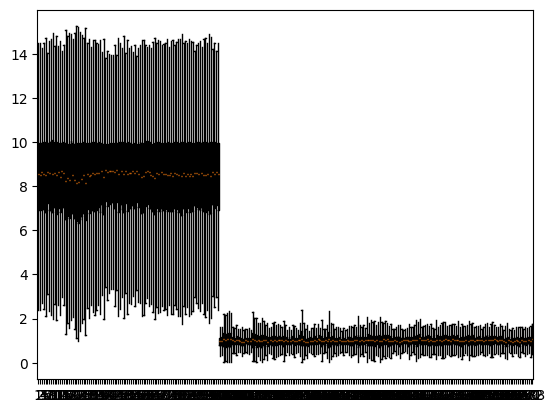

In [11]:
import matplotlib.pyplot as plt

plt.boxplot(
    [combined[c] for c in combined.columns],
    showfliers=False
)
plt.show()

# BATCH CORRECTION

In [12]:
batch = (
    ["GSE4271"] * tumor_expr.shape[1]
    + ["GSE11882"] * normal_expr.shape[1]
)

condition = (
    ["Tumor"] * tumor_expr.shape[1]
    + ["Normal"] * normal_expr.shape[1]
)

In [14]:
from pycombat import Combat

combat = Combat()

combat_expr = combat.fit_transform(
    combined.T.values,   # convert to numpy
    batch
)

combat_expr = pd.DataFrame(
    combat_expr.T,
    index=combined.index,
    columns=combined.columns
)

In [17]:
n_tumor = tumor_expr.shape[1]

tumor_corrected = combat_expr.iloc[:, :n_tumor]
normal_corrected = combat_expr.iloc[:, n_tumor:]

# EXPORT

In [19]:
# Export the shared genes and the gene-level expression matrices for downstream analysis
shared_genes_df = pd.DataFrame(sorted(shared_genes), columns=["gene_symbol"])
shared_genes_df.to_csv("../data/processed/shared_genes.csv", index=False)

normal_corrected.to_csv("../data/processed/normal_expr_by_gene.csv")
tumor_corrected.to_csv("../data/processed/tumor_expr.csv")

print("saved shared_genes.csv, normal_expr_by_gene.csv, and tumor_expr.csv")

saved shared_genes.csv, normal_expr_by_gene.csv, and tumor_expr.csv


In [20]:
general_df = mmc2_df.copy()
general_df = general_df.drop(["A","B"], axis=1)
general_df.to_csv("../data/processed/metadata.csv")

typeIII_labelled = general_df[(general_df["WHO grade"] == "III with necrosis") | (general_df["WHO grade"] == "III without necrosis")].copy()
III_no_label = general_df[general_df["WHO grade"] == "III"]
typeIII_labelled.loc[:, "necrosis"] = np.where(typeIII_labelled["WHO grade"] == "III with necrosis", "yes", "no")

IV_no_label = general_df[general_df["WHO grade"] == "IV"]
typeIV_labelled = general_df[(general_df["WHO grade"] == "IV with necrosis") | (general_df["WHO grade"] == "IV without necrosis")].copy()
typeIV_labelled.loc[:, "necrosis"] = np.where(typeIV_labelled["WHO grade"] == "IV with necrosis", "yes", "no")

print(f"\nNumber of III without label: {len(III_no_label.index)}")

count_III_without_necrosis = (typeIII_labelled["necrosis"] == "no").sum()
print(f"Number of III without necrosis: {count_III_without_necrosis}")

count_III_with_necrosis = (typeIII_labelled["necrosis"] == "yes").sum()
print(f"Number of III with necrosis: {count_III_with_necrosis}")

print(f"\nNumber of IV without label: {len(IV_no_label.index)}")

count_IV_without_necrosis = (typeIV_labelled["necrosis"] == "no").sum()
print(f"Number of IV without necrosis: {count_IV_without_necrosis}")

count_IV_with_necrosis = (typeIV_labelled["necrosis"] == "yes").sum()
print(f"Number of IV with necrosis: {count_IV_with_necrosis}")

general_df2 = mmc2_df.copy()
general_df2 = general_df2.drop(["A","B"], axis=1)


typeIII = general_df2[general_df2["WHO grade"].isin(["III", "III with necrosis", "III without necrosis"])]
III_primary = typeIII[typeIII["Primary/Recurrent"] == "primary"]
III_recurrent = typeIII[typeIII["Primary/Recurrent"] == "recurrent"]
print(f"Number of primary type III samples: {len(III_primary.index)}")
print(f"Number of recurrent type III samples: {len(III_recurrent.index)}")


print("\n")

typeIV = general_df2[general_df2["WHO grade"].isin(["IV", "IV with necrosis", "IV without necrosis"])]
IV_primary = typeIV[typeIV["Primary/Recurrent"] == "primary"]
IV_recurrent = typeIV[typeIV["Primary/Recurrent"] == "recurrent"]
print(f"Number of primary type IV samples: {len(IV_primary.index)}")
print(f"Number of recurrent type IV samples: {len(IV_recurrent.index)}")


# Primary
III_prim_PN = (III_primary[III_primary["Subtype"] == "PN"])
III_prim_Mes = (III_primary[III_primary["Subtype"] == "Mes"])
III_prim_Prolif = (III_primary[III_primary["Subtype"] == "Prolif"])
print("Primary:")
print(f"PN: {len(III_prim_PN.index)}")
print(f"Mes: {len(III_prim_Mes.index)}")
print(f"Prolif: {len(III_prim_Prolif.index)}")

print("\n")
# Recurrent
III_rec_PN = (III_recurrent[III_recurrent["Subtype"] == "PN"])
III_rec_Mes = (III_recurrent[III_recurrent["Subtype"] == "Mes"])
III_rec_Prolif = (III_recurrent[III_recurrent["Subtype"] == "Prolif"])
print("Recurrent:")
print(f"PN: {len(III_rec_PN.index)}")
print(f"Mes: {len(III_rec_Mes.index)}")
print(f"Prolif: {len(III_rec_Prolif.index)}")

# Primary
IV_prim_PN = (IV_primary[IV_primary["Subtype"] == "PN"])
IV_prim_Mes = (IV_primary[IV_primary["Subtype"] == "Mes"])
IV_prim_Prolif = (IV_primary[IV_primary["Subtype"] == "Prolif"])
print("Primary:")
print(f"PN: {len(IV_prim_PN.index)}")
print(f"Mes: {len(IV_prim_Mes.index)}")
print(f"Prolif: {len(IV_prim_Prolif.index)}")

print("\n")
# Recurrent
IV_rec_PN = (IV_recurrent[IV_recurrent["Subtype"] == "PN"])
IV_rec_Mes = (IV_recurrent[IV_recurrent["Subtype"] == "Mes"])
IV_rec_Prolif = (IV_recurrent[IV_recurrent["Subtype"] == "Prolif"])
print("Recurrent:")
print(f"PN: {len(IV_rec_PN.index)}")
print(f"Mes: {len(IV_rec_Mes.index)}")
print(f"Prolif: {len(IV_rec_Prolif.index)}")


Number of III without label: 24
Number of III without necrosis: 0
Number of III with necrosis: 0

Number of IV without label: 20
Number of IV without necrosis: 6
Number of IV with necrosis: 50
Number of primary type III samples: 21
Number of recurrent type III samples: 3


Number of primary type IV samples: 56
Number of recurrent type IV samples: 20
Primary:
PN: 20
Mes: 1
Prolif: 0


Recurrent:
PN: 2
Mes: 1
Prolif: 0
Primary:
PN: 10
Mes: 22
Prolif: 24


Recurrent:
PN: 5
Mes: 11
Prolif: 4
